<a href="https://colab.research.google.com/github/sahasraa178/Machine-Learning-sem-4/blob/main/ml_lab_assesment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MACHINE LEARNING ASSIGNMENT 10

BL.SC.U4AIE24009


B.SAHASRAA


Extracting the Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving BERT_Embeddings.xlsx to BERT_Embeddings.xlsx


A1

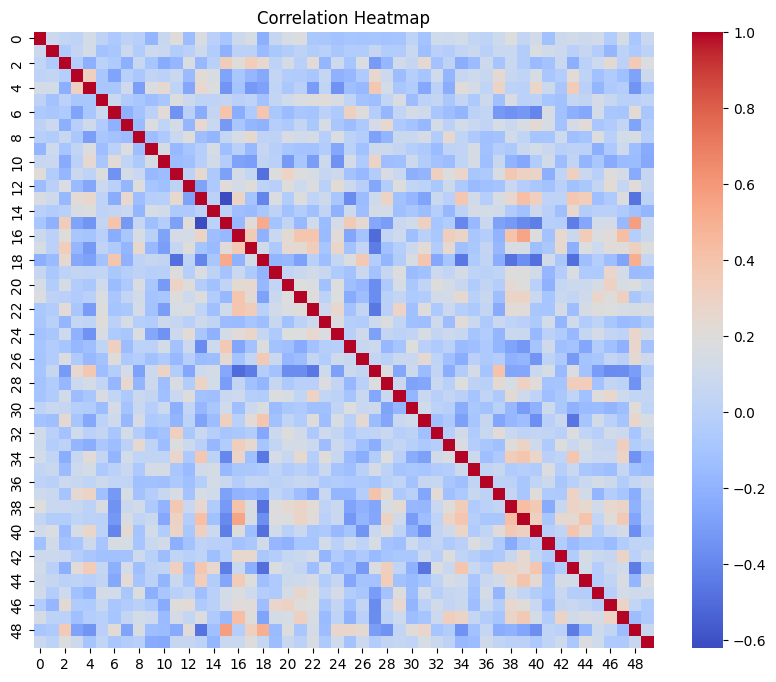

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(path):
    return pd.read_excel(path)

def get_features(data):
    return data.iloc[:, 0:768]

def compute_correlation(X):
    return X.corr()

def plot_heatmap(corr):
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='coolwarm')
    plt.title("Correlation Heatmap")


data = load_data("BERT_Embeddings.xlsx")
X = get_features(data)

corr_matrix = compute_correlation(X.iloc[:, :50])
plot_heatmap(corr_matrix)

plt.show()

A2

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

def load_data(path):
    return pd.read_excel(path)

def split_data(data):
    X = data.iloc[:, 0:768]
    y = data['label']
    return X, y

def apply_pca(X, variance):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=variance)
    return pca.fit_transform(X_scaled)

def train_models(X_train, X_test, y_train, y_test):
    models = {
        "Logistic": LogisticRegression(max_iter=1000),
        "RandomForest": RandomForestClassifier(),
        "SVM": SVC()
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results[name] = accuracy_score(y_test, preds)

    return results


data = load_data("BERT_Embeddings.xlsx")
X, y = split_data(data)

X_pca = apply_pca(X, 0.99)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

results = train_models(X_train, X_test, y_train, y_test)


results = {}
train_results = {}

# Fix: Define 'models' in the global scope so it's accessible for the subsequent loop
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds_test = model.predict(X_test)
    preds_train = model.predict(X_train)

    results[name] = accuracy_score(y_test, preds_test)       # test accuracy
    train_results[name] = accuracy_score(y_train, preds_train)  # train accuracy

print("Train Accuracies:")
print(train_results)
print("\nTest Accuracies:")
print(results)


Train Accuracies:
{'Logistic': 0.7447129909365559, 'RandomForest': 0.9966012084592145, 'SVM': 0.7734138972809668}

Test Accuracies:
{'Logistic': 0.49019607843137253, 'RandomForest': 0.5339366515837104, 'SVM': 0.555052790346908}


A3

In [10]:
X_pca = apply_pca(X, 0.95)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# Re-initialize models dictionary for this section to ensure it's available
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}
train_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds_test = model.predict(X_test)
    preds_train = model.predict(X_train)

    results[name] = accuracy_score(y_test, preds_test)       # test accuracy
    train_results[name] = accuracy_score(y_train, preds_train)  # train accuracy

print("Train Accuracies:")
print(train_results)
print("\nTest Accuracies:")
print(results)


Train Accuracies:
{'Logistic': 0.6661631419939577, 'RandomForest': 0.9966012084592145, 'SVM': 0.7628398791540786}

Test Accuracies:
{'Logistic': 0.4781297134238311, 'RandomForest': 0.530920060331825, 'SVM': 0.5595776772247361}


A4

In [12]:
# A4: Sequential Feature Selection (Optimized)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
def load_data(path):
    return pd.read_excel(path)

# =========================
# SPLIT FEATURES & LABEL
# =========================
def split_data(data):
    X = data.iloc[:, 0:768]
    y = data['label']
    return X, y

# =========================
# REDUCE FEATURES (IMPORTANT STEP)
# =========================
def reduce_features(X):
    return X.iloc[:, :100]   # reduce from 768 → 100

# =========================
# APPLY SEQUENTIAL SELECTION
# =========================
def select_features(X, y):
    base_model = DecisionTreeClassifier()

    sfs = SequentialFeatureSelector(
        base_model,
        n_features_to_select=10,
        direction='forward'
    )

    sfs.fit(X, y)
    return sfs.get_support(indices=True)

# =========================
# TRAIN FINAL MODEL
# =========================
def train_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    preds_test = model.predict(X_test)
    preds_train = model.predict(X_train)

    test_accuracy = accuracy_score(y_test, preds_test)
    train_accuracy = accuracy_score(y_train, preds_train)

    return train_accuracy, test_accuracy

# =========================
# MAIN
# =========================
data = load_data("BERT_Embeddings.xlsx")
X, y = split_data(data)

# Step 1: Reduce features
X_small = reduce_features(X)

# Step 2: Apply SFS
selected_indices = select_features(X_small, y)

# Step 3: Create selected dataset
X_selected = X_small.iloc[:, selected_indices]

# Step 4: Train model
train_accuracy, test_accuracy = train_model(X_selected, y)

print("Selected feature indices:", selected_indices)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)


Selected feature indices: [ 1  2 14 18 22 42 62 81 88 97]
Train Accuracy: 0.9966012084592145
Test Accuracy: 0.48868778280542985


A5

In [13]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c583d85c1c87e3fecab1cfa6747616a861d0459faed43131a9b4b982e8066c1c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [14]:
!pip install shap

LIME: [('625 <= 0.02', -0.006225692163582651), ('-0.04 < 565 <= 0.12', -0.005190889466354864), ('0.07 < 167 <= 0.16', 0.00499246003241021), ('758 > 0.20', 0.004974992806521295), ('0.03 < 81 <= 0.16', -0.0043781141670369995), ('0.05 < 165 <= 0.14', 0.004318142642370518), ('-0.12 < 731 <= -0.01', -0.0042950128389925195), ('376 <= -0.20', -0.004074728811248208), ('0.01 < 5 <= 0.09', -0.003799204141200873), ('0.09 < 708 <= 0.18', 0.0037620655570272284)]


 96%|=================== | 289/300 [00:13<00:00]       

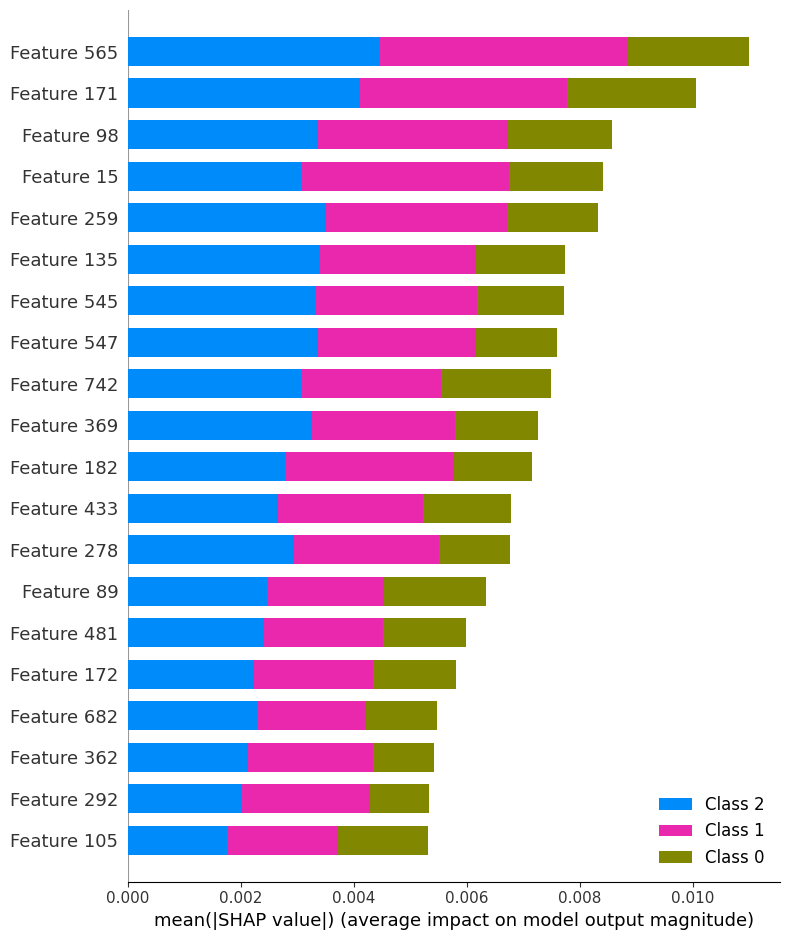

In [15]:
import pandas as pd
import numpy as np
import shap
from lime.lime_tabular import LimeTabularExplainer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

def load_data(path):
    return pd.read_excel(path)

def split_data(data):
    X = data.iloc[:, 0:768]
    y = data['label']
    return X, y

def train_model(X_train, y_train):
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    return model

def lime_explanation(X_train, X_test, model):
    explainer = LimeTabularExplainer(
        training_data=np.array(X_train),
        mode='classification'
    )

    explanation = explainer.explain_instance(
        X_test[0],
        model.predict_proba
    )

    return explanation

def shap_explanation(model, X_train):
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_train[:100])
    return shap_values


data = load_data("BERT_Embeddings.xlsx")
X, y = split_data(data)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

model = train_model(X_train, y_train)

lime_exp = lime_explanation(X_train, X_test, model)
print("LIME:", lime_exp.as_list())

shap_vals = shap_explanation(model, X_train)
shap.summary_plot(shap_vals, X_train)